In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
#shape
df = pd.read_csv('/content/drive/MyDrive/abt global notebooks - christa/STAR_2025JUL.csv')
df.shape

(4566, 27)

In [4]:
df.head()

,PROVIDER_ID,Std_Outcomes_Mortality_score,Std_Outcomes_Readmission_score,Std_Outcomes_Safety_score,Std_PatientExp_score,Std_Process_score,std_weight_PatientExperience,std_weight_Readmission,std_weight_Mortality,std_weight_safety,...,Outcomes_Mortality_cnt,Outcomes_safety_cnt,Outcomes_Readmission_cnt,Patient_Experience_cnt,Process_cnt,Total_measure_group_cnt,MortSafe_Group_cnt,report_indicator,cnt_grp,star
0,010001,0.296110,0.361406,0.344883,0.042072,-0.484678,0.22,0.22,0.22,0.22,...,7,7,11,8,11,5,2,1,3) # of groups=5,4.0
1,010005,-0.843034,0.631203,-0.403414,0.125181,-0.352656,0.22,0.22,0.22,0.22,...,6,7,9,8,12,5,2,1,3) # of groups=5,3.0
2,010006,-1.540677,-0.104890,0.685911,-1.301785,-0.458178,0.22,0.22,0.22,0.22,...,7,8,9,8,10,5,2,1,3) # of groups=5,2.0
3,010007,-3.330700,-0.931587,-0.329281,1.298719,-3.269085,0.22,0.22,0.22,0.22,...,3,3,7,8,7,5,2,1,3) # of groups=5,1.0
4,010008,-0.473161,-0.691563,NaN,NaN,-0.593935,0.22,0.22,0.22,0.22,...,1,0,2,0,6,1,0,0,NaN,NaN


In [5]:
df.columns.tolist()

['PROVIDER_ID',
 'Std_Outcomes_Mortality_score',
 'Std_Outcomes_Readmission_score',
 'Std_Outcomes_Safety_score',
 'Std_PatientExp_score',
 'Std_Process_score',
 'std_weight_PatientExperience',
 'std_weight_Readmission',
 'std_weight_Mortality',
 'std_weight_safety',
 'std_weight_Process',
 'weight_PatientExperience',
 'weight_Outcomes_Readmission',
 'weight_Outcomes_Mortality',
 'weight_Outcomes_Safety',
 'weight_Process',
 'summary_score',
 'Outcomes_Mortality_cnt',
 'Outcomes_safety_cnt',
 'Outcomes_Readmission_cnt',
 'Patient_Experience_cnt',
 'Process_cnt',
 'Total_measure_group_cnt',
 'MortSafe_Group_cnt',
 'report_indicator',
 'cnt_grp',
 'star']

In [6]:
#Unique PROVIDER_IDs / duplicates to make sure SAS produced one row per hospital.

print("Rows:", len(df))
print("Unique PROVIDER_IDs:", df["PROVIDER_ID"].nunique())
print("Duplicate PROVIDER_IDs:", df["PROVIDER_ID"].duplicated().sum())

Rows: 4566
Unique PROVIDER_IDs: 4566
Duplicate PROVIDER_IDs: 0


In [7]:
#Missingness
#Missing values are concentrated in the five group scores and their corresponding weights.
#This is expected because hospitals do not necessarily report measures for every group.

#Results reveal a missing group score results in that group's final weight also being missing.

missing = pd.DataFrame({
    "Missing": df.isna().sum(),
    "Percent": (df.isna().mean() * 100).round(2)
})

display(missing.sort_values("Missing", ascending=False))

,Missing,Percent
star,1675,36.68
cnt_grp,1675,36.68
Std_PatientExp_score,1387,30.38
weight_PatientExperience,1387,30.38
weight_Outcomes_Safety,1176,25.76
Std_Outcomes_Safety_score,1176,25.76
weight_Outcomes_Mortality,884,19.36
Std_Outcomes_Mortality_score,884,19.36
Std_Outcomes_Readmission_score,244,5.34
weight_Outcomes_Readmission,244,5.34


In [14]:
#Distribution of:
   # report_indicator
   # cnt_grp
   # star

df["report_indicator"].value_counts(dropna=False)

,count
report_indicator,
1,2891
0,1675


In [15]:
df["report_indicator"].value_counts(
    normalize=True, dropna=False
).mul(100).round(2)

,proportion
report_indicator,
1,63.32
0,36.68


In [16]:
pd.crosstab(
    df["report_indicator"],
    df["star"].isna(),
    margins=True
)

star,False,True,All
report_indicator,,,
0,0,1675,1675
1,2891,0,2891
All,2891,1675,4566


In [8]:
#All 2,891 eligible hospitals have a star rating, while all 1,675 ineligible hospitals have a missing star rating.
#Therefore, the missing star values are intentional rather than a data-cleaning issue.

df.groupby("report_indicator").agg(
    hospitals=("PROVIDER_ID", "count"),
    missing_star=("star", lambda x: x.isna().sum()),
    has_star=("star", lambda x: x.notna().sum())
)

,hospitals,missing_star,has_star
report_indicator,,,
0,1675,1675,0
1,2891,0,2891


In [10]:
#CMS groups eligible hospitals based on whether they have 3, 4, or 5 measure groups.
#After examining peer group selections, among the eligible hospitals, 141 are assigned to the 3-group peer group, 515 to the 4-group peer group,
#and 2,235 to the 5-group peer group. Hospitals that are not eligible for reporting have no cnt_grp value.

df["cnt_grp"].value_counts(dropna=False).sort_index()

,count
cnt_grp,
1) # of groups=3,141
2) # of groups=4,515
3) # of groups=5,2235
NaN,1675


In [11]:
pd.crosstab(
    df["cnt_grp"],
    df["report_indicator"],
    margins=True
)

report_indicator,1,All
cnt_grp,,
1) # of groups=3,141,141
2) # of groups=4,515,515
3) # of groups=5,2235,2235
All,2891,2891


In [12]:
#Number of individual measures available within each group.
#Last two columns are higher-level counts.

count_cols = [c for c in df.columns if "_cnt" in c]
count_cols

['Outcomes_Mortality_cnt',
 'Outcomes_safety_cnt',
 'Outcomes_Readmission_cnt',
 'Patient_Experience_cnt',
 'Process_cnt',
 'Total_measure_group_cnt',
 'MortSafe_Group_cnt']

In [13]:
#Hospitals have different numbers of available measures within each group.
#Readmission and Process contain the largest possible numbers of measures (up to 11 and 12),
#while Mortality has up to 7, Safety up to 8, and Patient Experience up to 8.
#This variation is expected because hospitals do not all report the same measures.

df[count_cols].describe()

,Outcomes_Mortality_cnt,Outcomes_safety_cnt,Outcomes_Readmission_cnt,Patient_Experience_cnt,Process_cnt,Total_measure_group_cnt,MortSafe_Group_cnt
count,4566.000000,4566.000000,4566.000000,4566.000000,4566.000000,4566.000000,4566.000000
mean,3.524310,3.506789,5.908235,5.569864,7.912396,3.561323,1.127683
std,2.576021,2.965641,3.378450,3.679469,3.025375,1.686901,0.916988
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,0.000000,3.000000,0.000000,5.000000,2.000000,0.000000
50%,4.000000,3.000000,6.000000,8.000000,9.000000,4.000000,1.000000
75%,6.000000,7.000000,9.000000,8.000000,10.000000,5.000000,2.000000
max,7.000000,8.000000,11.000000,8.000000,12.000000,5.000000,2.000000


In [14]:
#Patient Experience differs from the other groups.
#Hospitals either have all 8 Patient Experience measures (3,179 hospitals) or none of them (1,387 hospitals).
#The other groups show a wider range of available measure counts.

#For Total_measure_group_cnt: hospitals can have between 0 and 5 available measure groups.
#Most hospitals (2,235) have all five groups, while some hospitals have fewer groups or none.

#MortSafe_Group_cnt indicates availability of the Mortality and Safety groups.
#Hospitals may have neither group, one of the two groups, or both groups.

for col in count_cols:
    print(f"\n{col}")
    print(df[col].value_counts(dropna=False).sort_index())


Outcomes_Mortality_cnt
Outcomes_Mortality_cnt
0    884
1    503
2    432
3    452
4    398
5    456
6    590
7    851
Name: count, dtype: int64

Outcomes_safety_cnt
Outcomes_safety_cnt
0    1176
1     452
2     536
3     294
4     223
5     236
6     462
7     734
8     453
Name: count, dtype: int64

Outcomes_Readmission_cnt
Outcomes_Readmission_cnt
0     244
1     330
2     383
3     379
4     342
5     353
6     445
7     365
8     468
9     426
10    333
11    498
Name: count, dtype: int64

Patient_Experience_cnt
Patient_Experience_cnt
0    1387
8    3179
Name: count, dtype: int64

Process_cnt
Process_cnt
0      22
1      54
2     166
3     274
4     273
5     355
6     340
7     295
8     398
9     549
10    765
11    727
12    348
Name: count, dtype: int64

Total_measure_group_cnt
Total_measure_group_cnt
0     202
1     670
2     476
3     468
4     515
5    2235
Name: count, dtype: int64

MortSafe_Group_cnt
MortSafe_Group_cnt
0    1665
1     653
2    2248
Name: count, dtype: int

In [15]:
score_cols = [
    c for c in df.columns
    if c.startswith("Std_") and c.endswith("_score")
]

score_cols

['Std_Outcomes_Mortality_score',
 'Std_Outcomes_Readmission_score',
 'Std_Outcomes_Safety_score',
 'Std_PatientExp_score',
 'Std_Process_score']

In [16]:
df["calculated_group_count"] = df[score_cols].notna().sum(axis=1)

pd.crosstab(
    df["calculated_group_count"],
    df["cnt_grp"],
    margins=True
)

cnt_grp,1) # of groups=3,2) # of groups=4,3) # of groups=5,All
calculated_group_count,,,,
3,55,0,0,55
4,75,65,0,140
5,11,450,2235,2696
All,141,515,2235,2891


In [39]:
#Check weights:
#Do group weights behave as expected when groups are missing?

#The final weights cannot simply be hard-coded to the original policy weights for every hospital.
#The SAS logic adjusts the final weights when groups are unavailable.

weight_cols = [
    "weight_PatientExperience",
    "weight_Outcomes_Readmission",
    "weight_Outcomes_Mortality",
    "weight_Outcomes_Safety",
    "weight_Process"
]

df["weight_sum"] = df[weight_cols].sum(axis=1)

df["weight_sum"].describe()

,weight_sum
count,4.566000e+03
mean,1.000000e+00
std,4.185168e-11
min,1.000000e+00
25%,1.000000e+00
50%,1.000000e+00
75%,1.000000e+00
max,1.000000e+00


In [41]:
df.groupby("cnt_grp")["weight_sum"].describe()

,count,mean,std,min,25%,50%,75%,max
cnt_grp,,,,,,,,
1) # of groups=3,141.0,1.0,3.525849e-11,1.0,1.0,1.0,1.0,1.0
2) # of groups=4,515.0,1.0,3.324128e-11,1.0,1.0,1.0,1.0,1.0
3) # of groups=5,2235.0,1.0,0.000000e+00,1.0,1.0,1.0,1.0,1.0


In [42]:
#Check summary_score:
    #Can it be reproduced from group scores × weights?

print(score_cols)
print(weight_cols)

['Std_Outcomes_Mortality_score', 'Std_Outcomes_Readmission_score', 'Std_Outcomes_Safety_score', 'Std_PatientExp_score', 'Std_Process_score']
['weight_PatientExperience', 'weight_Outcomes_Readmission', 'weight_Outcomes_Mortality', 'weight_Outcomes_Safety', 'weight_Process']


In [32]:
pairs = [
    ("Std_Outcomes_Mortality_score", "weight_Outcomes_Mortality"),
    ("Std_Outcomes_Safety_score", "weight_Outcomes_Safety"),
    ("Std_Outcomes_Readmission_score", "weight_Outcomes_Readmission"),
    ("Std_PatientExp_score", "weight_PatientExperience"),
    ("Std_Process_score", "weight_Process")
]

In [33]:
df["calculated_summary_score"] = sum(
    df[score].fillna(0) * df[weight].fillna(0)
    for score, weight in pairs
)

df["summary_difference"] = (
    df["summary_score"] - df["calculated_summary_score"]
).abs()

df["summary_difference"].describe()

,summary_difference
count,4.566000e+03
mean,1.619005e-10
std,1.609846e-10
min,0.000000e+00
25%,3.799994e-11
50%,1.040000e-10
75%,2.519347e-10
max,1.278770e-09


In [34]:
#The SAS summary-score calculation can be reproduced as the sum of each available standardized group score multiplied by its corresponding final group weight.

(df["summary_difference"] < 1e-6).value_counts()

,count
summary_difference,
True,4566


In [35]:
#Check stars: Only eligible hospitals should receive stars

#Among the 2,891 hospitals eligible for public reporting, star ratings range from 1–5.
#Three-star hospitals are the largest category (939), followed by four-star (767) and two-star (661) hospitals.
#The 1,675 missing ratings correspond exactly to hospitals with report_indicator = 0.

df["star"].value_counts(dropna=False).sort_index()

,count
star,
1.0,233
2.0,661
3.0,939
4.0,767
5.0,291
NaN,1675


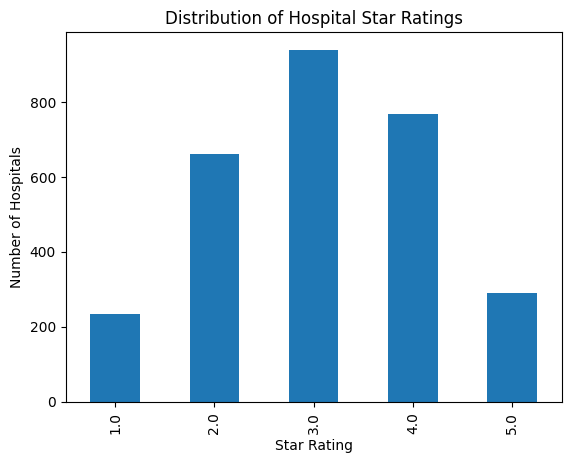

In [36]:
df["star"].dropna().value_counts().sort_index().plot(kind="bar")

plt.xlabel("Star Rating")
plt.ylabel("Number of Hospitals")
plt.title("Distribution of Hospital Star Ratings")
plt.show()

In [37]:
#Check peer groups:
    #Hospitals should be grouped into 3, 4, or 5
    #measure-group cohorts

pd.crosstab(
    df["cnt_grp"],
    df["star"],
    margins=True
)

star,1.0,2.0,3.0,4.0,5.0,All
cnt_grp,,,,,,
1) # of groups=3,7,23,40,50,21,141
2) # of groups=4,45,118,191,125,36,515
3) # of groups=5,181,520,708,592,234,2235
All,233,661,939,767,291,2891
